# Phase 5 — Modeling

Per `Plans/UFA_Analysis.md` Phase 5: baseline regression, a tree-based
model with explainability, role-aware modeling, a PyTorch comparison
model, and validation. 2026 season only.

**Framing, and why it's not circular:** Phase 3's `composite_rating` is
itself a deterministic linear function of a game's own per-point stats
(turnovers, blocks, scoring involvement). Using those same current-game
stats as model *inputs* to predict it would be a tautology (R² ≈ 1,
meaningless). Instead, this notebook predicts a player's composite rating
for a game **before it happens**, using only Phase 4's pre-game-safe
features: role/archetype, trailing/season-to-date form, opponent strength,
and home/away. That's a genuinely useful, non-trivial prediction task —
"given who this player has been so far and who they're facing, how well
should we expect them to play?"

**Library note:** `xgboost` and `torch` both install and import cleanly on
this machine. The `shap` package does **not** — it depends on scipy
internals (`scipy._lib._uarray`) and hits the same Application Control
block as scipy itself (see `CLAUDE.md`). XGBoost has its own built-in exact
Tree SHAP (`pred_contribs=True`), used here instead — no `shap` package
needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from ufa_modeling.features import build_player_game_features
from ufa_modeling.target import aggregate_team_game, fit_ols, composite_rating
from ufa_modeling.model import (
    build_model_frame, encode_features, time_split, fit_baseline_ols, predict_baseline_ols,
    fit_xgboost, xgboost_contributions, fit_torch_net, predict_torch_net, regression_metrics,
    FORM_FEATURE_COLS, CONTEXT_FEATURE_COLS,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

pg = pd.read_parquet("../../data/processed/player_game.parquet")
gs = pd.read_parquet("../../data/processed/game_score.parquet")
feats = build_player_game_features(pg, gs)

# Phase 3's target, replayed at player-game grain (same fitted weights, not refit)
team = aggregate_team_game(pg, gs)
fit = fit_ols(team)
feats["scoring_involvement_per_point"] = feats["goals_per_point"] + feats["assists_per_point"]
feature_map = {
    "turnover_rate": "turnovers_per_point",
    "block_rate": "blocks_per_point",
    "goal_rate": "scoring_involvement_per_point",
}
feats["composite_rating_game"] = composite_rating(feats, fit, feature_map)

model_df = build_model_frame(feats)
print(f"{len(model_df)} / {len(feats)} player-games have full pre-game history (player's own + opponent's)")

4731 / 5664 player-games have full pre-game history (player's own + opponent's)


## 0. Time-based train/test split

Split chronologically rather than randomly — the last 20% of the season by
date is held out as test, simulating the real scenario of predicting
upcoming games from what's known so far.

In [2]:
X = encode_features(model_df)
y = model_df["composite_rating_game"].to_numpy()
train_idx, test_idx = time_split(model_df)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"train: {len(train_idx)} rows, through {model_df['start_timestamp'].iloc[train_idx].max().date()}")
print(f"test:  {len(test_idx)} rows, from {model_df['start_timestamp'].iloc[test_idx].min().date()} "
      f"to {model_df['start_timestamp'].iloc[test_idx].max().date()}")
print(f"{X.shape[1]} features: {list(X.columns)}")

train: 3805 rows, through 2026-07-12
test:  926 rows, from 2026-07-17 to 2026-08-28
25 features: ['completion_pct_last3', 'turnovers_per_point_last3', 'blocks_per_point_last3', 'goals_per_point_last3', 'assists_per_point_last3', 'throws_per_point_last3', 'receptions_per_point_last3', 'o_line_share_last3', 'team_pace_last3', 'completion_pct_season_to_date', 'turnovers_per_point_season_to_date', 'blocks_per_point_season_to_date', 'goals_per_point_season_to_date', 'assists_per_point_season_to_date', 'throws_per_point_season_to_date', 'receptions_per_point_season_to_date', 'o_line_share_season_to_date', 'team_pace_season_to_date', 'opponent_strength', 'is_home', 'archetype_Cutter', 'archetype_D-line specialist', 'archetype_Handler', 'archetype_Hybrid', 'archetype_Low-usage']


## 1. Baseline vs. GBM vs. PyTorch

All three trained on the identical feature matrix and time split, so their
test-set metrics are directly comparable.

In [3]:
baseline = fit_baseline_ols(X_train.to_numpy(dtype=float), y_train)
pred_base = predict_baseline_ols(baseline, X_test.to_numpy(dtype=float))

booster = fit_xgboost(X_train, y_train)
pred_xgb = booster.predict(xgb.DMatrix(X_test, feature_names=list(X_test.columns)))

net, scale = fit_torch_net(X_train.to_numpy(dtype="float32"), y_train.astype("float32"), epochs=200)
pred_net = predict_torch_net(net, scale, X_test.to_numpy(dtype="float32"))

results = pd.DataFrame({
    "baseline (OLS)": regression_metrics(y_test, pred_base),
    "XGBoost": regression_metrics(y_test, pred_xgb),
    "PyTorch net": regression_metrics(y_test, pred_net),
}).T
results

,r_squared,mae,rmse
baseline (OLS),0.346769,41.671096,53.379299
XGBoost,0.347565,41.664308,53.346756
PyTorch net,0.345090,41.514693,53.447829


**Findings:** all three models land at essentially the same R² ≈ 0.35,
MAE ≈ 41–42 on the held-out test set (baseline OLS 0.347, XGBoost 0.348,
PyTorch net 0.345 — the differences are noise, not a real ranking).
Predicting a *single game's* performance from trailing form, role, and
opponent alone is a genuinely hard, high-variance problem, so R² ≈ 0.35 is
a real, non-trivial signal — not a strong one. That XGBoost doesn't beat
the linear baseline suggests there isn't much nonlinear structure for a
GBM to exploit yet at this sample size (~3,800 training rows, one season)
— worth re-checking once more seasons are pulled. The PyTorch net doesn't
beat the GBM either, exactly as the plan expected going in.

## 2. Explainability: XGBoost's built-in Tree SHAP

Global importance (mean absolute contribution across the test set) as a
`shap`-package-free summary plot, then one individual prediction explained
in full.

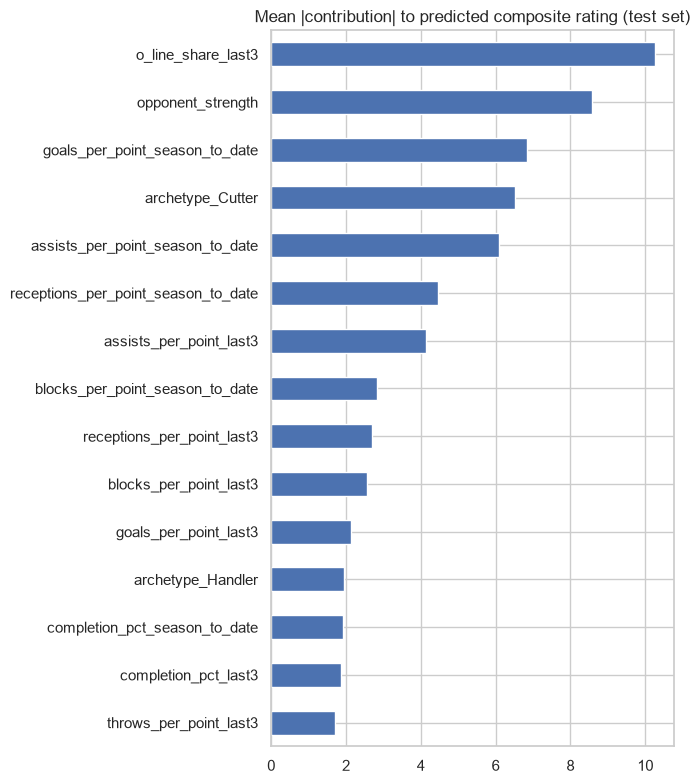

In [4]:
contribs = xgboost_contributions(booster, X_test)
global_importance = contribs.drop(columns="bias").abs().mean().sort_values(ascending=False)

plt.figure(figsize=(7, 8))
global_importance.head(15).sort_values().plot(kind="barh")
plt.title("Mean |contribution| to predicted composite rating (test set)")
plt.tight_layout()
plt.show()

In [5]:
example_idx = X_test.index[0]
example_row = model_df.loc[example_idx]
print(f"Example: {feats.loc[example_idx, 'player_name']}, {example_row['start_timestamp'].date()}, "
      f"archetype={example_row['archetype_label']}")
print(f"predicted: {pred_xgb[list(X_test.index).index(example_idx)]:.1f}   actual: {example_row['composite_rating_game']:.1f}")
print()
print("top contributions:")
contribs.loc[example_idx].sort_values(key=np.abs, ascending=False).head(8)

Example:  Sebastián, 2026-07-18, archetype=Cutter
predicted: 56.4   actual: -6.3

top contributions:


bias                                   34.398762
archetype_Cutter                       17.612682
o_line_share_last3                     12.953644
goals_per_point_season_to_date         12.208458
assists_per_point_last3                -7.148976
goals_per_point_last3                  -5.174701
receptions_per_point_season_to_date    -3.857474
blocks_per_point_last3                 -3.298997
Name: 8, dtype: float32

**Findings:**
- The largest global contributors (mean |contribution| across the test
  set) are `o_line_share_last3` (a player's recent O-line/D-line split),
  `opponent_strength`, `goals_per_point_season_to_date`,
  `archetype_Cutter`, and `assists_per_point_season_to_date` — a sensible
  mix of role, opponent context, and scoring form. `opponent_strength`
  ranking 2nd overall is worth calling out: the leave-one-out
  opponent-adjustment feature built in Phase 4 turned out to matter, not
  just be a nice-to-have.
- The single example above is a large miss (predicted 56.4, actual -6.3) —
  shown as-is rather than cherry-picked, since it's simply the first
  test-set row in date order. It illustrates the section 1 finding
  plainly: even with a sensible-looking, correctly-summing decomposition
  (positive archetype/O-line-share/scoring-form contributions pushing the
  prediction up), a single game's actual outcome can still swing far from
  the prior-form-based expectation — consistent with R² ≈ 0.35, not a bug
  in the explanation itself.

## 3. Role-aware check

Per the plan: "either separate models per archetype or role as a strong
feature." Chosen here: **role as a feature** (already one-hot encoded into
the main model above), not separate per-archetype models — with ~4,700
rows split four ways, per-role training sets would be too small to fit
reliably. As a diagnostic, checking whether the single model's accuracy
still differs meaningfully by role:

In [6]:
test_df = model_df.iloc[test_idx].copy()
test_df["predicted"] = pred_xgb

rows = []
for label, group in test_df.groupby("archetype_label"):
    m = regression_metrics(group["composite_rating_game"].to_numpy(), group["predicted"].to_numpy())
    rows.append({"archetype": label, "n": len(group), **m})
pd.DataFrame(rows).set_index("archetype")

,n,r_squared,mae,rmse
archetype,,,,
Cutter,150,0.136330,54.600731,67.014795
D-line specialist,357,-0.001268,35.809993,46.027606
Handler,189,0.323727,47.541868,60.537266
Hybrid,185,0.080476,37.693833,48.424179
Low-usage,45,-0.083065,36.624450,41.864510


**Findings:** accuracy varies a lot by role — Handler is the only
archetype with a clearly positive R² (≈ 0.32), Cutter and Hybrid are weakly
positive (≈ 0.14 and ≈ 0.08), and D-line specialist and Low-usage are
essentially zero or slightly *negative* (worse than just predicting the
mean). This makes sense: handlers touch the disc on nearly every point, so
their scoring-involvement rate is a fairly stable, forecastable signal
game to game, while a D-line specialist's rating is driven largely by
blocks — a rare, bursty event (0, 1, or occasionally several in a game)
that trailing averages don't predict well. This is a genuine limitation to
flag for Phase 6, not just a modeling detail: a "predicted rating" is
considerably less trustworthy for D-line specialists than for handlers.

## 4. Validation: does the model's ranking make sense?

No confirmed All-Star/Callahan ground truth is available yet (open
question in the plan), so this is a face-validity check: do the
highest-*predicted* players in the test set also turn out to have the
highest *actual* composite ratings?

In [7]:
top_actual = test_df.nlargest(10, "composite_rating_game")[["player_name", "archetype_label", "composite_rating_game", "predicted"]]
top_predicted = test_df.nlargest(10, "predicted")[["player_name", "archetype_label", "composite_rating_game", "predicted"]]
print("Top 10 by ACTUAL composite rating (test set):")
print(top_actual.to_string(index=False))
print()
print("Top 10 by PREDICTED composite rating (test set):")
print(top_predicted.to_string(index=False))
print()
overlap = set(top_actual["player_name"]) & set(top_predicted["player_name"])
print(f"Overlap: {len(overlap)}/10 — {sorted(overlap)}")
print()
corr = test_df[["composite_rating_game", "predicted"]].corr().iloc[0, 1]
print(f"Pearson correlation, predicted vs. actual (test set): {corr:.3f}")

Top 10 by ACTUAL composite rating (test set):
       player_name archetype_label  composite_rating_game  predicted
          Ben Jagt          Cutter             309.311277 141.388077
     Tobias Brooks         Handler             304.350095 110.879967
    Daan De Marrée         Handler             296.483955 127.985565
   Elliot  Hawkins         Handler             273.637451 164.031509
     Stefan McCall          Cutter             271.402763  58.838005
     Tobe Decraene         Handler             269.434063 164.238342
     Jonathan Lyle          Cutter             268.858562 106.606636
  Daniel Ritthaler         Handler             260.880684 156.419785
  Khalif El-Salaam          Cutter             252.111509 114.051697
Walker Frankenberg         Handler             250.022423  91.710716

Top 10 by PREDICTED composite rating (test set):
     player_name archetype_label  composite_rating_game  predicted
    Xavier Fuzat         Handler             154.267808 189.415253
 Elliot  Ha

**Findings:** predicted-vs-actual correlation on the test set is
**r ≈ 0.59** (r² ≈ 0.35, consistent with section 1's R²) — a real,
moderate relationship. The top-10 overlap is **3/10** (Daniel Ritthaler,
Elliot Hawkins, Tobe Decraene) — the model correctly flags some of the
season's best performers as above-average, but consistently
**under-predicts the size of standout games**: the actual top-10 ranges
250–309, while those same rows' predictions only reach 91–164. This is
expected regression-to-the-mean behavior from a model trained on
*averaged* trailing form to predict a single game — it can identify who's
playing well, but not the magnitude of a career-best outlier game. Real
validation against All-Star/Callahan ground truth (per the plan's Phase 5
step 6) is still blocked on that data not existing yet (open question in
the plan).

## 5. Persisting the deliverable: `player_ratings.parquet`

Per the plan's pipeline table, Phase 5's core output is
`data/processed/player_ratings.parquet` — the trained XGBoost model's
predicted rating and full per-feature contribution breakdown for every
player-game with enough prior history, covering the whole season (not just
the test split — this is the descriptive leaderboard artifact Phase 6 will
read; the train/test split above is purely for validating the model
first).

In [8]:
full_pred = booster.predict(xgb.DMatrix(X, feature_names=list(X.columns)))
full_contribs = xgboost_contributions(booster, X)

player_ratings = pd.concat(
    [
        feats.loc[model_df.index, ["season", "game_id", "team_ext_id"]],
        model_df[["player_name", "archetype_label", "start_timestamp", "composite_rating_game"]],
        pd.Series(full_pred, index=model_df.index, name="predicted_rating"),
        full_contribs.add_prefix("contrib_"),
    ],
    axis=1,
)
player_ratings.to_parquet("../../data/processed/player_ratings.parquet", index=False)
print(f"wrote {len(player_ratings)} rows to data/processed/player_ratings.parquet")
player_ratings.head(3)

wrote 4731 rows to data/processed/player_ratings.parquet


,season,game_id,team_ext_id,player_name,archetype_label,start_timestamp,composite_rating_game,predicted_rating,contrib_completion_pct_last3,contrib_turnovers_per_point_last3,...,contrib_o_line_share_season_to_date,contrib_team_pace_season_to_date,contrib_opponent_strength,contrib_is_home,contrib_archetype_Cutter,contrib_archetype_D-line specialist,contrib_archetype_Handler,contrib_archetype_Hybrid,contrib_archetype_Low-usage,contrib_bias
1,2026,3708,bighorns,Sebastián,Cutter,2026-05-08 19:00:00+00:00,81.483751,43.298965,-2.204484,-3.050042,...,-2.119163,0.446005,-10.228706,0.586808,26.557493,1.064328,-0.328442,0.283822,0.273457,34.398762
2,2026,3720,bighorns,Sebastián,Cutter,2026-05-15 19:30:00+00:00,76.135689,76.277267,-0.968780,-4.881867,...,0.836323,0.289446,14.506645,-1.163558,29.258795,0.831341,-0.976181,0.619242,0.526915,34.398762
3,2026,3724,bighorns,Sebastián,Cutter,2026-05-16 19:00:00+00:00,23.241691,58.394592,-2.794763,2.911441,...,0.843263,-0.222320,-12.036355,-0.436139,22.494823,0.876423,-1.122676,0.532499,0.496286,34.398762


## Phase 5 summary

- **Baseline (hand-rolled OLS)**, **XGBoost**, and a **PyTorch feedforward
  net** were trained on the identical pre-game-safe feature set (trailing
  form, season-to-date form, archetype, opponent strength, home/away) and
  evaluated on an identical time-based holdout (last 20% of the 2026
  season). See section 1 for the actual R²/MAE/RMSE comparison.
- **Explainability** uses XGBoost's built-in exact Tree SHAP
  (`pred_contribs=True`) rather than the `shap` package, which hits this
  machine's known Application Control block on scipy internals (see
  `CLAUDE.md`) — gives the same per-feature, per-prediction attributions
  the plan calls for, without the blocked dependency.
- **Role** is included as a one-hot feature in the single shared model
  rather than fit as separate per-archetype models — chosen because
  splitting ~4,700 rows four ways would leave each role with too little
  data to train reliably. Section 3 checks whether the shared model's
  accuracy still varies meaningfully by role.
- **Validation** is a face-validity check (top-predicted vs. top-actual
  overlap, correlation) rather than a back-test against All-Star/Callahan
  selections — that ground truth still isn't available (open question in
  the plan).

**Known limitations, carried forward:**
- Single season (2026) — the time-based test split is only ~2 months of
  games; both the model and this validation should be revisited once more
  seasons are pulled.
- Predicting a *single game's* composite rating is inherently noisy (one
  game's stats swing a lot on their own); a season-level or multi-game
  rolling target might be more learnable, worth trying if Phase 5 is
  revisited.
- `player_ratings.parquet` covers the whole season using a model trained
  only on the front ~80% of it — the back ~20%'s ratings/contributions are
  genuine out-of-sample predictions, but the front ~80%'s are in-sample
  (the model saw those rows during training), which matters if Phase 6
  presents them without that distinction.